In [81]:
import sys
from pathlib import Path
from difflib import get_close_matches
import scipy.io
from scipy.stats import ks_2samp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score


df = pd.read_csv('../prepared_data/story_aggregated_data.csv')

In [82]:
df.head()

,story_name,fool_hero_mean,fool_hero_std,angel_demon_mean,angel_demon_std,trad_adventurer_mean,trad_adventurer_std,lone_wolf_diva_mean,lone_wolf_diva_std,outcast_soph_mean,outcast_soph_std,brute_geek_mean,brute_geek_std,cast_size,is_comedy
0,(500) Days of Summer,8.353373,12.346157,-7.509349,6.439074,13.161957,19.002881,11.691623,9.962875,-11.954536,21.885571,8.717333,2.582246,2,1
1,10 Things I Hate About You,14.097583,23.374889,9.354443,31.610384,8.895335,24.075384,11.150856,27.514599,-5.885553,12.538668,-5.884582,16.216885,6,1
2,8 Mile,33.487735,0.000000,18.474906,0.000000,23.600837,0.000000,-23.653452,0.000000,-15.241622,0.000000,4.840814,0.000000,1,0
3,A Series of Unfortunate Events,37.294823,31.800358,3.632574,54.001095,-2.139105,13.041584,2.745035,4.849898,-10.481052,8.611981,16.124795,5.170841,3,1
4,A Star Is Born,16.504863,13.921006,1.235229,21.970246,27.318987,3.920331,-7.981630,5.684261,-11.096272,7.850583,3.498290,5.756921,2,0


In [83]:
mat_path = '../datasets/archetypometricsdata2000.mat'
mat = scipy.io.loadmat(str(mat_path), simplify_cells=True)

archetype_space = mat["data_archetype_space"]["character_component_norms"]
ds = mat["data_stories"]
story_names = ds["storyverses"]
story_char_idx = ds["storycharacterindices"]

story_index = {
    story_names[i]: (story_char_idx[i] - 1)
    for i in range(len(story_names))
}

def radius_gyration(A):
    centroid = np.mean(A, axis=1, keepdims=True)
    differences = A - centroid
    squared_distances = np.sum(differences ** 2, axis=0)
    return np.sqrt(np.mean(squared_distances))


In [84]:
gyration_vals = {}
print_the_statement = False
for story_name in df['story_name']:  # or df.index if story_name is the index        
    char_idx = np.atleast_1d(story_index[story_name])
    scores = archetype_space[:6, char_idx]  # (6, n_chars)
    gyration_vals[story_name] = radius_gyration(scores)
df['cast_gyration'] = df['story_name'].map(gyration_vals)  # adjust if story_name is index


In [85]:
A = [
    [ -3.99278395,  20.69953079],
    [-13.94842259,  -1.07027551],
    [ -5.84092386,  32.16483811],
    [ 21.65449782,   1.72874741],
    [-33.84010735,   9.93103435],
    [  6.13508725,  11.29957882]
]

print(np.mean(A, axis=1, keepdims=True))
centroid = np.mean(A, axis=1, keepdims=True)
print(A - centroid)

[[  8.35337342]
 [ -7.50934905]
 [ 13.16195712]
 [ 11.69162261]
 [-11.9545365 ]
 [  8.71733303]]
[[-12.34615737  12.34615737]
 [ -6.43907354   6.43907354]
 [-19.00288098  19.00288098]
 [  9.9628752   -9.9628752 ]
 [-21.88557085  21.88557085]
 [ -2.58224578   2.58224579]]


In [86]:
df.head()

,story_name,fool_hero_mean,fool_hero_std,angel_demon_mean,angel_demon_std,trad_adventurer_mean,trad_adventurer_std,lone_wolf_diva_mean,lone_wolf_diva_std,outcast_soph_mean,outcast_soph_std,brute_geek_mean,brute_geek_std,cast_size,is_comedy,cast_gyration
0,(500) Days of Summer,8.353373,12.346157,-7.509349,6.439074,13.161957,19.002881,11.691623,9.962875,-11.954536,21.885571,8.717333,2.582246,2,1,33.762462
1,10 Things I Hate About You,14.097583,23.374889,9.354443,31.610384,8.895335,24.075384,11.150856,27.514599,-5.885553,12.538668,-5.884582,16.216885,6,1,57.467249
2,8 Mile,33.487735,0.000000,18.474906,0.000000,23.600837,0.000000,-23.653452,0.000000,-15.241622,0.000000,4.840814,0.000000,1,0,0.000000
3,A Series of Unfortunate Events,37.294823,31.800358,3.632574,54.001095,-2.139105,13.041584,2.745035,4.849898,-10.481052,8.611981,16.124795,5.170841,3,1,64.976067
4,A Star Is Born,16.504863,13.921006,1.235229,21.970246,27.318987,3.920331,-7.981630,5.684261,-11.096272,7.850583,3.498290,5.756921,2,0,28.617123


In [87]:
comedy = df[df['is_comedy'] == 1]
drama  = df[df['is_comedy'] == 0]

feature_cols = [c for c in df.columns if c not in ('is_comedy', 'story_name')]
results = []

for col in feature_cols:
    stat, pval = ks_2samp(comedy[col].values, drama[col].values)
    results.append({'feature': col, 'ks_stat': stat, 'p_value': pval})

ks_df = (pd.DataFrame(results)
           .sort_values('ks_stat', ascending=False)
           .reset_index(drop=True))

ks_df['significant'] = ks_df['p_value'] < 0.05
ks_df.round(4)


,feature,ks_stat,p_value,significant
0,trad_adventurer_mean,0.3554,0.0000,True
1,fool_hero_mean,0.2985,0.0001,True
2,lone_wolf_diva_mean,0.2759,0.0003,True
3,cast_gyration,0.2578,0.0009,True
4,outcast_soph_std,0.1783,0.0476,True
5,angel_demon_mean,0.1761,0.0520,False
6,trad_adventurer_std,0.1600,0.0976,False
7,angel_demon_std,0.1448,0.1666,False
8,brute_geek_mean,0.1070,0.4954,False
9,fool_hero_std,0.1037,0.5355,False


In [88]:
df.head()

,story_name,fool_hero_mean,fool_hero_std,angel_demon_mean,angel_demon_std,trad_adventurer_mean,trad_adventurer_std,lone_wolf_diva_mean,lone_wolf_diva_std,outcast_soph_mean,outcast_soph_std,brute_geek_mean,brute_geek_std,cast_size,is_comedy,cast_gyration
0,(500) Days of Summer,8.353373,12.346157,-7.509349,6.439074,13.161957,19.002881,11.691623,9.962875,-11.954536,21.885571,8.717333,2.582246,2,1,33.762462
1,10 Things I Hate About You,14.097583,23.374889,9.354443,31.610384,8.895335,24.075384,11.150856,27.514599,-5.885553,12.538668,-5.884582,16.216885,6,1,57.467249
2,8 Mile,33.487735,0.000000,18.474906,0.000000,23.600837,0.000000,-23.653452,0.000000,-15.241622,0.000000,4.840814,0.000000,1,0,0.000000
3,A Series of Unfortunate Events,37.294823,31.800358,3.632574,54.001095,-2.139105,13.041584,2.745035,4.849898,-10.481052,8.611981,16.124795,5.170841,3,1,64.976067
4,A Star Is Born,16.504863,13.921006,1.235229,21.970246,27.318987,3.920331,-7.981630,5.684261,-11.096272,7.850583,3.498290,5.756921,2,0,28.617123


In [89]:
# define features and target
target = 'is_comedy'
exclude = {'is_comedy', 'story_name'}

baseline_features = [c for c in df.columns if c not in exclude and c != 'cast_gyration']
gyration_features = [c for c in df.columns if c not in exclude]

std_features = [c for c in df.columns if c.endswith('_std')]
no_std_features = [c for c in gyration_features if c not in std_features]

X_baseline = df[baseline_features].values
X_gyration  = df[gyration_features].values
X_no_std    = df[no_std_features].values
y = df[target].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ])
}

scoring = ['roc_auc', 'f1', 'accuracy']
results = []

for model_name, model in models.items():
    for feat_name, X in [
        ('baseline', X_baseline),
        ('+ gyration', X_gyration),
        ('gyration replaces std', X_no_std),
    ]:
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
        results.append({
            'model': model_name,
            'features': feat_name,
            'AUC':      scores['test_roc_auc'].mean(),
            'AUC_std':  scores['test_roc_auc'].std(),
            'F1':       scores['test_f1'].mean(),
            'F1_std':   scores['test_f1'].std(),
            'Accuracy': scores['test_accuracy'].mean(),
            'Acc_std':  scores['test_accuracy'].std(),
        })

results_df = pd.DataFrame(results)
results_df.round(3)


,model,features,AUC,AUC_std,F1,F1_std,Accuracy,Acc_std
0,Logistic Regression,baseline,0.724,0.037,0.492,0.078,0.688,0.036
1,Logistic Regression,+ gyration,0.726,0.037,0.502,0.055,0.696,0.035
2,Logistic Regression,gyration replaces std,0.746,0.024,0.543,0.077,0.716,0.039


In [90]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_std)

# tried 2, 3, 4 clusters, 3 was best for ARI and interpretability
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)


In [91]:
ari = adjusted_rand_score(y, cluster_labels)
print(f"Adjusted Rand Index: {ari:.3f}")
print("\nCluster vs Genre:")
print(pd.crosstab(
    pd.Series(cluster_labels, name='Cluster'),
    pd.Series(y, name='Genre').map({1: 'Comedy', 0: 'Drama'})
))


Adjusted Rand Index: 0.090

Cluster vs Genre:
Genre    Comedy  Drama
Cluster               
0            10     23
1            17     86
2            60     51


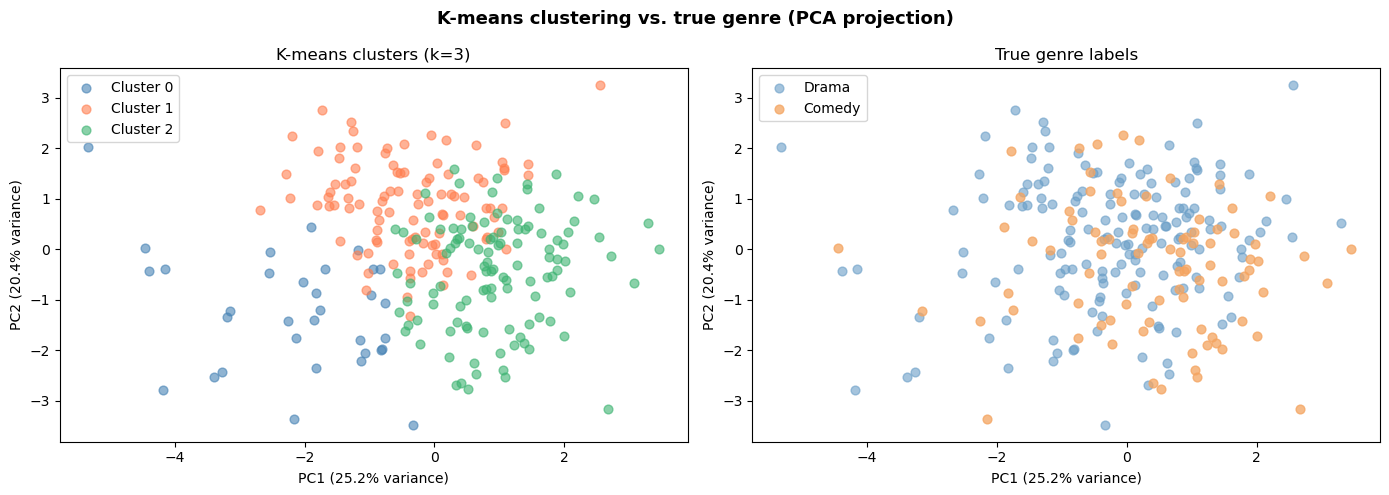

Variance explained by PC1+PC2: 45.6%


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colored by k-means cluster
for cluster_id, color in zip([0, 1, 2], ['steelblue', 'coral', 'mediumseagreen']):
    mask = cluster_labels == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=color, alpha=0.6, s=40, label=f'Cluster {cluster_id}')
axes[0].set_title('K-means clusters (k=3)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend()

# Right: colored by true genre
axes[1].scatter(X_pca[y==0, 0], X_pca[y==0, 1],
                color='#6A9EC7', alpha=0.6, s=40, label='Drama')
axes[1].scatter(X_pca[y==1, 0], X_pca[y==1, 1],
                color='#F4A460', alpha=0.75, s=40, label='Comedy')
axes[1].set_title('True genre labels')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend()

plt.suptitle('K-means clustering vs. true genre (PCA projection)', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('../figures/pca_clusters_vs_genre_story_level.png', dpi=300)
plt.show()

print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_[:2].sum():.1%}")


In [93]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

np.random.seed(42)
fold_results = []
all_y_test = []
all_y_pred = []

for train_idx, test_idx in cv.split(X_no_std, y):
    X_train, X_test = X_no_std[train_idx], X_no_std[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit distribution on comedy training examples only
    comedy_train = X_train[y_train == 1]
    comedy_mean = np.mean(comedy_train, axis=0)
    comedy_cov  = np.cov(comedy_train.T)

    # Sample enough synthetic comedies to balance classes
    n_needed = (y_train == 0).sum() - (y_train == 1).sum()
    synthetic_X = np.random.multivariate_normal(comedy_mean, comedy_cov, size=n_needed)
    synthetic_y = np.ones(n_needed)

    # Augment training set
    X_train_aug = np.vstack([X_train, synthetic_X])
    y_train_aug = np.concatenate([y_train, synthetic_y])

    # Scale — fit on augmented training, apply to test
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_aug)
    X_test_scaled  = scaler.transform(X_test)

    # Train and evaluate
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_scaled, y_train_aug)

    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)

    fold_results.append({
        'AUC':      roc_auc_score(y_test, y_prob),
        'F1':       f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred)
    })

bootstrap_results = pd.DataFrame(fold_results)
print("Bootstrap oversampling (gyration replaces std):")
print(bootstrap_results.describe().loc[['mean', 'std']].round(3))


Bootstrap oversampling (gyration replaces std):
        AUC     F1  Accuracy
mean  0.745  0.617     0.697
std   0.038  0.040     0.052


In [94]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

cm = confusion_matrix(all_y_test, all_y_pred)
tn, fp, fn, tp = cm.ravel()

print("Pooled confusion matrix (5-fold CV, bootstrap oversampling):")
print(f"\n{'':25s} Predicted Comedy  Predicted Drama")
print(f"{'Actual Comedy':25s} {tp:^16d}  {fn:^15d}")
print(f"{'Actual Drama':25s} {fp:^16d}  {tn:^15d}")

prec = precision_score(all_y_test, all_y_pred)
rec  = recall_score(all_y_test, all_y_pred)
f1   = f1_score(all_y_test, all_y_pred)
acc  = accuracy_score(all_y_test, all_y_pred)
print(f"\nPrecision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}  Accuracy: {acc:.3f}")


Pooled confusion matrix (5-fold CV, bootstrap oversampling):

                          Predicted Comedy  Predicted Drama
Actual Comedy                    60               27       
Actual Drama                     48               112      

Precision: 0.556  Recall: 0.690  F1: 0.615  Accuracy: 0.696


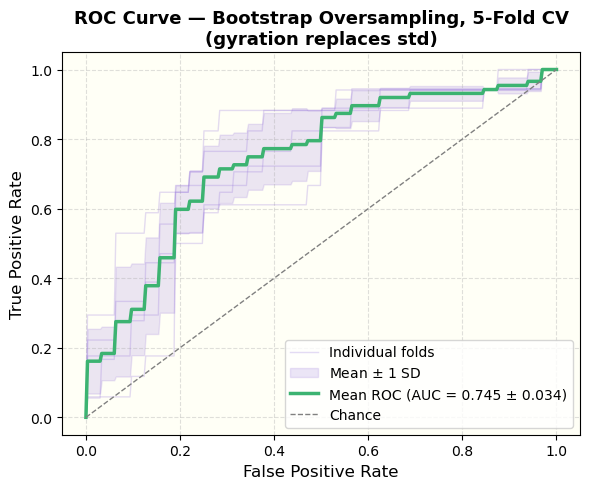

In [99]:
from sklearn.metrics import roc_curve, auc

mean_fpr = np.linspace(0, 1, 300)
fold_tprs = []
fold_aucs = []

np.random.seed(42)
for train_idx, test_idx in cv.split(X_no_std, y):
    X_train, X_test = X_no_std[train_idx], X_no_std[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    comedy_train = X_train[y_train == 1]
    comedy_mean  = np.mean(comedy_train, axis=0)
    comedy_cov   = np.cov(comedy_train.T)
    n_needed     = (y_train == 0).sum() - (y_train == 1).sum()
    synthetic_X  = np.random.multivariate_normal(comedy_mean, comedy_cov, size=n_needed)
    synthetic_y  = np.ones(n_needed)

    X_train_aug = np.vstack([X_train, synthetic_X])
    y_train_aug = np.concatenate([y_train, synthetic_y])

    scaler_roc = StandardScaler()
    X_tr_sc = scaler_roc.fit_transform(X_train_aug)
    X_te_sc = scaler_roc.transform(X_test)

    clf_roc = LogisticRegression(max_iter=1000)
    clf_roc.fit(X_tr_sc, y_train_aug)

    fpr, tpr, _ = roc_curve(y_test, clf_roc.predict_proba(X_te_sc)[:, 1])
    fold_tprs.append(np.interp(mean_fpr, fpr, tpr))
    fold_tprs[-1][0] = 0.0
    fold_aucs.append(auc(fpr, tpr))

mean_tpr = np.mean(fold_tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr  = np.std(fold_tprs, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor((1.0, 1.0, 0.965))

for i, tpr_fold in enumerate(fold_tprs):
    ax.plot(mean_fpr, tpr_fold, color='mediumpurple', alpha=0.25, linewidth=1,
            label='Individual folds' if i == 0 else None)

ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                color='mediumpurple', alpha=0.18, label=r'Mean $\pm$ 1 SD')
ax.plot(mean_fpr, mean_tpr, color='mediumseagreen', linewidth=2.5,
        label=f'Mean ROC (AUC = {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Chance')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Bootstrap Oversampling, 5-Fold CV\n(gyration replaces std)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/genre_prediction_roc_bootstrap_gyration.png', dpi=300)
plt.show()


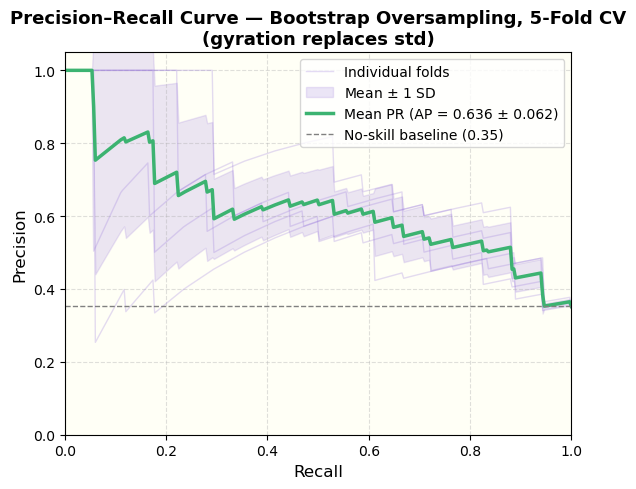

In [101]:
from sklearn.metrics import precision_recall_curve, average_precision_score

mean_recall = np.linspace(0, 1, 300)
fold_precisions = []
fold_aps = []

np.random.seed(42)
for train_idx, test_idx in cv.split(X_no_std, y):
    X_train, X_test = X_no_std[train_idx], X_no_std[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    comedy_train = X_train[y_train == 1]
    comedy_mean  = np.mean(comedy_train, axis=0)
    comedy_cov   = np.cov(comedy_train.T)
    n_needed     = (y_train == 0).sum() - (y_train == 1).sum()
    synthetic_X  = np.random.multivariate_normal(comedy_mean, comedy_cov, size=n_needed)
    synthetic_y  = np.ones(n_needed)

    X_train_aug = np.vstack([X_train, synthetic_X])
    y_train_aug = np.concatenate([y_train, synthetic_y])

    scaler_pr = StandardScaler()
    X_tr_sc = scaler_pr.fit_transform(X_train_aug)
    X_te_sc = scaler_pr.transform(X_test)

    clf_pr = LogisticRegression(max_iter=1000)
    clf_pr.fit(X_tr_sc, y_train_aug)

    y_prob_pr = clf_pr.predict_proba(X_te_sc)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob_pr)
    # precision_recall_curve returns recall in decreasing order; flip for interp
    fold_precisions.append(np.interp(mean_recall, recall[::-1], precision[::-1]))
    fold_aps.append(average_precision_score(y_test, y_prob_pr))

mean_precision = np.mean(fold_precisions, axis=0)
std_precision  = np.std(fold_precisions, axis=0)
baseline_precision = y.mean()  # no-skill line = class prevalence

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor((1.0, 1.0, 0.965))

for i, prec_fold in enumerate(fold_precisions):
    ax.plot(mean_recall, prec_fold, color='mediumpurple', alpha=0.25, linewidth=1,
            label='Individual folds' if i == 0 else None)

ax.fill_between(mean_recall, mean_precision - std_precision, mean_precision + std_precision,
                color='mediumpurple', alpha=0.18, label=r'Mean $\pm$ 1 SD')
ax.plot(mean_recall, mean_precision, color='mediumseagreen', linewidth=2.5,
        label=f'Mean PR (AP = {np.mean(fold_aps):.3f} ± {np.std(fold_aps):.3f})')
ax.axhline(baseline_precision, linestyle='--', color='gray', linewidth=1,
           label=f'No-skill baseline ({baseline_precision:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision–Recall Curve — Bootstrap Oversampling, 5-Fold CV\n(gyration replaces std)', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/genre_prediction_pr_bootstrap_gyration.png', dpi=300)
plt.show()


In [96]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_std)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

ari = adjusted_rand_score(y, cluster_labels)
print(f"Adjusted Rand Index: {ari:.3f}")
print("\nCluster vs Genre:")
print(pd.crosstab(
    pd.Series(cluster_labels, name='Cluster'),
    pd.Series(y, name='Genre').map({1: 'Comedy', 0: 'Drama'})
))


Adjusted Rand Index: 0.060

Cluster vs Genre:
Genre    Comedy  Drama
Cluster               
0            15     67
1            12     39
2            27     23
3            33     31


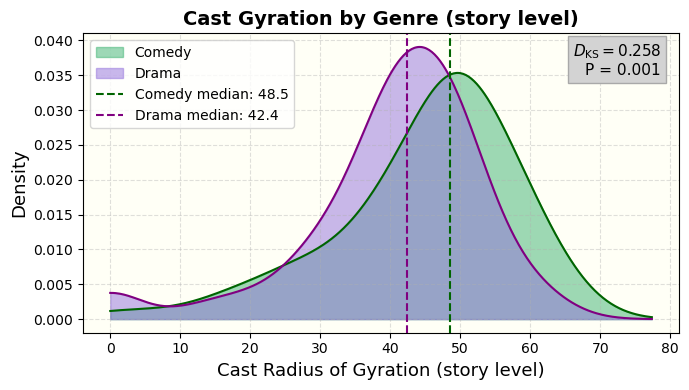

In [97]:
comedy_gyration = df[df['is_comedy'] == 1]['cast_gyration'].values
drama_gyration  = df[df['is_comedy'] == 0]['cast_gyration'].values

ks_row = ks_df[ks_df['feature'] == 'cast_gyration'].iloc[0]

x = np.linspace(0, max(comedy_gyration.max(), drama_gyration.max()) + 10, 400)
kde_comedy = gaussian_kde(comedy_gyration)(x)
kde_drama  = gaussian_kde(drama_gyration)(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_facecolor((1.0, 1.0, 0.965))

ax.fill_between(x, kde_comedy, alpha=0.5, color='mediumseagreen', label='Comedy')
ax.fill_between(x, kde_drama,  alpha=0.5, color='mediumpurple',   label='Drama')
ax.plot(x, kde_comedy, color='darkgreen', linewidth=1.5)
ax.plot(x, kde_drama,  color='purple',    linewidth=1.5)

ax.axvline(np.median(comedy_gyration), color='darkgreen', linestyle='--', linewidth=1.5,
           label=f'Comedy median: {np.median(comedy_gyration):.1f}')
ax.axvline(np.median(drama_gyration),  color='purple',    linestyle='--', linewidth=1.5,
           label=f'Drama median: {np.median(drama_gyration):.1f}')

p_str = r"$P < 10^{-4}$" if ks_row['p_value'] < 1e-4 else f"P = {ks_row['p_value']:.3f}"
ks_text = rf"$D_{{\mathrm{{KS}}}} = {ks_row['ks_stat']:.3f}$" + "\n" + p_str
ax.text(0.97, 0.97, ks_text, transform=ax.transAxes,
        fontsize=11, va='top', ha='right',
        bbox=dict(boxstyle="square,pad=0.3", facecolor="lightgrey", edgecolor="darkgray"))

ax.set_xlabel("Cast Radius of Gyration (story level)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("Cast Gyration by Genre (story level)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../figures/cast_gyration_by_genre_story_level.pdf', bbox_inches='tight')
plt.show()


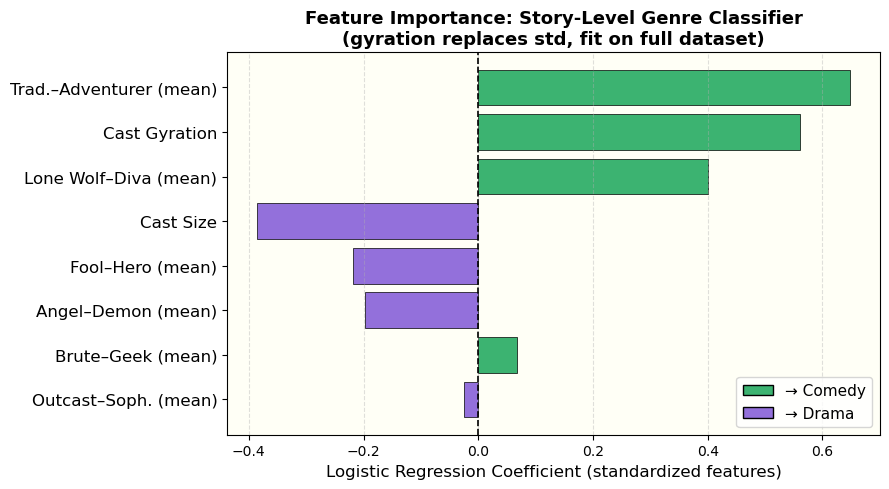

In [ ]:
import matplotlib.patches as mpatches

feature_labels = {
    'fool_hero_mean':       'Fool–Hero (mean)',
    'angel_demon_mean':     'Angel–Demon (mean)',
    'trad_adventurer_mean': 'Trad.–Adventurer (mean)',
    'lone_wolf_diva_mean':  'Lone Wolf–Diva (mean)',
    'outcast_soph_mean':    'Outcast–Soph. (mean)',
    'brute_geek_mean':      'Brute–Geek (mean)',
    'cast_size':            'Cast Size',
    'cast_gyration':        'Cast Gyration',
}

scaler_coef = StandardScaler()
X_scaled_coef = scaler_coef.fit_transform(X_no_std)
clf_coef = LogisticRegression(max_iter=1000, random_state=42)
clf_coef.fit(X_scaled_coef, y)

coefs = clf_coef.coef_[0]
labels = [feature_labels.get(f, f) for f in no_std_features]

order = np.argsort(np.abs(coefs))
coefs_sorted = coefs[order]
labels_sorted = [labels[i] for i in order]
colors = ['mediumseagreen' if c > 0 else 'mediumpurple' for c in coefs_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor((1.0, 1.0, 0.965))
ax.barh(range(len(coefs_sorted)), coefs_sorted, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted, fontsize=12)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel("Logistic Regression Coefficient (standardized features)", fontsize=12)
ax.set_title(
    "Feature Importance: Story-Level Genre Classifier\n(gyration replaces std, fit on full dataset)",
    fontsize=13, fontweight='bold'
)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

comedy_patch = mpatches.Patch(facecolor='mediumseagreen', edgecolor='black', label='→ Comedy')
drama_patch  = mpatches.Patch(facecolor='mediumpurple',   edgecolor='black', label='→ Drama')
ax.legend(handles=[comedy_patch, drama_patch], fontsize=11, loc='lower right')

plt.tight_layout()
# plt.savefig('../figures/logistic_coef_story_level.pdf', bbox_inches='tight')
plt.show()
